# LC-DA-CA1 Model (v3)

Author: Dinghao Luo  
Date: 31 March 2026

This notebook contains a phenomenological LC-DA-CA1 model used to test whether one compact circuit-level architecture can reproduce the main PyrUp and PyrDown findings across bootstrapped simulations.

The final model has three time-varying drives: a run-related excitatory drive, a reward-related suppressive drive, and a dopamine drive generated from the Gaussian LC phasic signal by one exponential convolution and then delayed before it acts on CA1. Cells differ in baseline excitability, coupling weights, dopamine targeting, and intrinsic recovery time constant. Only the intrinsic recovery time constant is coupled to baseline: lower-baseline cells are assigned slightly higher $\tau_i$ across the full population.

## Formulation

**1. Build the shared drives**

- Run drive, $R(t)$: a smooth positive pulse that begins slightly before run onset, rises toward its peak, and then decays.
- Reward drive, $W(t)$: a smooth negative pulse that suppresses activity after run onset and then recovers.
- DA release drive, $D_{\mathrm{release}}(t)$: take the LC phasic Gaussian above baseline and apply one exponential kernel,

$$
D_{\mathrm{release}}(t) = g_{\mathrm{LC\rightarrow DA}} \left(\max\big(L(t)-L_0, 0\big) * k_{\exp}\right)(t)
$$

$$
k_{\exp}(t) = \tau_{DA}^{-1} e^{-t/\tau_{DA}} H(t)
$$

then delay that released DA trace before it acts on CA1,

$$
\widetilde{D}(t) = D_{\mathrm{release}}(t - \Delta_{DA})
$$

**2. Build the effective DA weight**

The targeted extra DA weight is read directly from the previous timestep firing rate,

$$
w_{\mathrm{extra},i}^{DA}(t_k) = \sigma\!\left(\frac{r_i(t_{k-1}) - r_{1/2}}{k_r}\right), \qquad k > 0
$$

$$
w_i^{DA}(t_k) = w_{\mathrm{global}}^{DA} + I_i^{\mathrm{targ}} w_{\mathrm{extra},i}^{DA}(t_k)
$$

with the first timestep initialized from the DA-free rate proxy. For readability, the preview panel labels this x-axis simply as firing rate (Hz), even though the model update itself uses the previous discrete timestep rate, $r_i(t_{k-1})$.

**3. Form the total CA1 drive**

$$
z_i(t_k) = b_i + w_i^R R(t_k) + w_i^W W(t_k) + w_i^{DA}(t_k) \, \widetilde{D}(t_k)
$$

**4. Apply the intrinsic recovery time constant**

The intrinsic recovery constant is sampled with one global baseline-to-tau relationship,

$$
\tau_i = \operatorname{clip}\!\left(\tau_0 + c_\tau \frac{\bar{b} - b_i}{\sigma_b} + \eta_i, \tau_{\min}, \tau_{\max}\right)
$$

so lower-baseline cells are assigned slightly larger $\tau_i$ regardless of class identity. The latent state then evolves as

$$
\tau_i \frac{d u_i(t)}{dt} = -u_i(t) + z_i(t)
$$

**5. Read out the firing rate**

$$
r_i(t) = \operatorname{softplus}\!\big(u_i(t)\big)
$$

Symbol definitions:
- $b_i$: baseline excitability of cell $i$
- $w_i^R$: weight on the run-related drive $R(t)$
- $w_i^W$: weight on the reward-related drive $W(t)$
- $w_i^{DA}(t_k)$: effective DA coupling at timestep $k$
- $w_{\mathrm{extra},i}^{DA}(t_k)$: targeted extra DA coupling read out from the previous timestep firing rate
- $I_i^{\mathrm{targ}}$: binary indicator of whether cell $i$ is DA-targeted
- $L(t)$: Gaussian LC phasic signal
- $L_0$: LC baseline level
- $\tau_{DA}$: decay constant of the single exponential LC-to-DA kernel
- $\Delta_{DA}$: delay from DA release to effective CA1 modulation
- $c_\tau$: global baseline-to-tau coupling coefficient
- $\tau_i$: cell-specific intrinsic recovery constant
- $u_i(t)$: latent CA1 state before output rectification
- $r_i(t)$: final firing rate used for classification and plotting

This is a compact phenomenological model rather than a detailed biophysical circuit model. Its purpose is to test whether one coherent LC-DA-CA1 architecture can reproduce the manuscript-level shifts in PyrUp and PyrDown proportions and firing-rate profiles.


In [21]:
# imports
import warnings
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import linregress, ttest_rel, wilcoxon

import plotting_functions as pf
from common_functions import mpl_formatting
mpl_formatting()
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

PLOT_SAVE_DIR = Path('Z:/Dinghao/code_dinghao/modelling')
PLOT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore', message='Matplotlib is currently using agg')

In [22]:
@dataclass
class PARAMS:
    # simulation grid
    dt: float     = 0.01  # time step
    t_pre: float  = 1.00  # simulation start time (negative) relative to run onset
    t_post: float = 6.00  # simulation end time relative to run onset

    # bootstrap controls
    n_bootstrap: int          = 50  # how many times to run bootstrapping for each exp?
    seed_start: int           = 0  # which seed to use by default (rng)
    lc_activation_fold: float = 3  # optogenetic LC stim. (exp 1) fold

    # population size
    n_cells: int = 1000  # population size

    # population priors
    baseline_mean: float = 1.05  # CA1 pyramidal baseline mean
    baseline_sd: float   = 0.75  # CA1 pyramidal baseline std

    wR_mean: float = 0.54  # run-related coupling mean (absorbs the former run-drive amplitude)
    wR_sd: float   = 0.10
    wW_mean: float = 0.22  # reward-related coupling mean (absorbs the former reward-drive amplitude)
    wW_sd: float   = 0.90

    # additive DA drive
    frac_da_targ: float  = 0.225  # proportion of CA1 cells targeted by DA
    da_half_rate: float  = 4.20  # r_1/2; midpoint of the targeted extra DA weight vs previous firing rate
    da_rate_slope: float = 1.20  # k_r; steepness of the sigmoid
    wDA_global: float    = 0.010  # diffuse DA coupling shared across the population
    da_block_scale: float = 0.00  # 1 - how much DA is blocked in exp 3

    # cell-intrinsic recovery acting on the full latent CA1 state
    intrinsic_tau_mean: float   = 0.38  # mean intrinsic CA1 tau before baseline-dependent nudging
    baseline_tau_coupling: float = 0.14  # lower-baseline cells receive slightly higher tau, globally across the population
    intrinsic_tau_sd: float      = 0.05
    intrinsic_tau_min: float     = 0.05
    intrinsic_tau_max: float     = 1.00

    # output nonlinearity / output limits
    softplus_beta: float = 2.00
    max_rate: float      = 20.00  # capping CA1 pyramidal cell firing rate

    # run-drive shape
    run_on_mid: float     = 0.12  # midpoint of the rising sigmoid
    run_off_mid: float    = 2.50  # midpoint of the falling sigmoid
    run_rise_scale: float = 0.10  # how sharp is the rise?
    run_fall_scale: float = 0.80  # how sharp is the fall?

    # reward-drive shape
    reward_on_mid: float     = 0.28
    reward_off_mid: float    = 1.60
    reward_rise_scale: float = 0.05
    reward_fall_scale: float = 0.75

    # LC drive shape
    lc_baseline: float = 1.00  # baseline amplitude of LC activity
    lc_amp: float      = 1.50  # delta(peak, baseline) of LC phasic activity
    lc_mu: float       = 0.00  # centre (relative to run onset)
    lc_sigma: float    = 0.20  # sigma of Gaussian

    # LC -> DA release conversion (single transformation only)
    lc_to_da_gain: float = 5.60  # scales the DA release trace after the exponential transform
    da_kernel_tau: float = 3.00  # slow, flat decay for the single exponential LC -> DA kernel
    da_ca1_delay: float  = 0.60  # additional delay from released DA to effective CA1 modulation

    # population analysis
    pre_window: tuple  = (-1.00, -0.50)  # this does not matter much, since pre-run-onset activity is usually flat
    post_window: tuple = (0.50, 1.50)  # same as used in real experiments
    up_thresh: float   = 3 / 2  # same
    down_thresh: float = 2 / 3  # same

    # numerical safeguard
    eps: float = 1e-6


class_colors = {
    'is_up':    'firebrick',
    'is_other': 'grey',
    'is_down':  'purple'
}

condition_colors = {
    'baseline': '0.35',
    'lc': 'royalblue',
    'blocked': class_colors['is_down'],
    'da_targeted': class_colors['is_up'],
    'not_targeted': '0.45'
}


In [23]:
# helper functions

def window_mask(t, window):
    return (t >= window[0]) & (t < window[1])


def response_strength(rates, t, p):
    '''calculates the response strength'''
    pre_mask  = window_mask(t, p.pre_window)
    post_mask = window_mask(t, p.post_window)
    pre_mean  = np.mean(rates[:, pre_mask], axis=1)
    post_mean = np.mean(rates[:, post_mask], axis=1)
    return post_mean / (pre_mean + p.eps)


def classify_cells(resp, p):
    '''classifies cells and returns one-hot encoding of cell identity as a dict'''
    is_up = resp >= p.up_thresh
    is_down = resp <= p.down_thresh
    return {
        'is_up': is_up,
        'is_down': is_down,
        'is_other': ~(is_up | is_down),
    }


def safe_mean_trace(rate_matrix, mask):
    '''just a masked mean FR profile calculation function; "safe" as it handles some edge cases where a class has no cells'''
    if np.sum(mask) == 0:
        return np.full(rate_matrix.shape[1], np.nan)
    return np.mean(rate_matrix[mask], axis=0)


def sem(values, axis=0):
    values = np.asarray(values, dtype=float)
    count = np.sum(np.isfinite(values), axis=axis)
    spread = np.nanstd(values, axis=axis, ddof=1)
    out = spread / np.sqrt(np.maximum(count, 1))
    if np.isscalar(out):
        return np.nan if count <= 1 else float(out)
    out = np.asarray(out, dtype=float)
    return np.where(count > 1, out, np.nan)


def mean_sem(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)), float(sem(values, axis=0))


def plot_mean_sem(ax, t, traces, color, label, linestyle='-', alpha_fill=0.18):
    traces = np.asarray(traces, dtype=float)
    mean_trace = np.nanmean(traces, axis=0)
    sem_trace = sem(traces, axis=0)
    ax.plot(t, mean_trace, color=color, linewidth=2, linestyle=linestyle, label=label)
    ax.fill_between(t, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=alpha_fill, linewidth=0)


def baseline_subtracted_traces(traces, t, window):
    '''for plotting'''
    traces = np.asarray(traces, dtype=float)
    baseline = np.mean(traces[:, window_mask(t, window)], axis=1, keepdims=True)
    return traces - baseline


def print_paired_summary(label, left, right):
    def fmt_p(p):
        if not np.isfinite(p):
            return 'nan'
        return f'{p:.2e}'

    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    mask = np.isfinite(left) & np.isfinite(right)
    left = left[mask]
    right = right[mask]
    if len(left) == 0:
        print(f'{label}: delta = nan, paired t p = nan, Wilcoxon p = nan')
        return

    t_res = ttest_rel(right, left, nan_policy='omit')
    try:
        w_res = wilcoxon(right, left, zero_method='wilcox', method='approx')
        w_p = float(w_res.pvalue)
    except ValueError:
        w_p = np.nan

    print(
        f'{label}: '
        f'delta = {np.mean(right - left):.2f}, '
        f'paired t p = {fmt_p(float(t_res.pvalue))}, '
        f'Wilcoxon p = {fmt_p(w_p)}'
    )



def paired_trace_window_means(traces, t, window):
    traces = np.asarray(traces, dtype=float)
    return np.nanmean(traces[:, window_mask(t, window)], axis=1)


def print_trace_window_test(label, left_traces, right_traces, t, window):
    left = paired_trace_window_means(left_traces, t, window)
    right = paired_trace_window_means(right_traces, t, window)
    print_paired_summary(label, left, right)


def set_trace_ylim(ax, *trace_sets, pad_frac=0.08, lower_floor=0.0):
    lows = []
    highs = []
    for traces in trace_sets:
        traces = np.asarray(traces, dtype=float)
        if traces.size == 0:
            continue
        if traces.ndim == 1:
            mean_trace = traces
            sem_trace = np.zeros_like(mean_trace)
        else:
            mean_trace = np.nanmean(traces, axis=0)
            sem_trace = sem(traces, axis=0)
        lows.append(float(np.nanmin(mean_trace - sem_trace)))
        highs.append(float(np.nanmax(mean_trace + sem_trace)))

    if not lows or not highs:
        return

    ymin = min(lows)
    ymax = max(highs)
    span = ymax - ymin
    if not np.isfinite(span) or span <= 0:
        span = max(abs(ymax), 1.0) * 0.1
    pad = span * pad_frac
    ax.set_ylim(max(lower_floor, ymin - pad), ymax + pad)


def paired_ylim(*arrays, lower_floor=0.0, pad_frac=0.35, min_pad=2.5, anchor_floor=None):
    finite = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float).ravel()
        arr = arr[np.isfinite(arr)]
        if arr.size:
            finite.append(arr)
    if not finite:
        return None
    values = np.concatenate(finite)
    vmin = float(np.min(values))
    vmax = float(np.max(values))
    span = vmax - vmin
    pad = max(span * pad_frac, min_pad)
    ymin = vmin - pad
    if anchor_floor is not None:
        ymin = min(float(anchor_floor), ymin)
    return (max(lower_floor, ymin), vmax + pad)


def save_figure_bundle(fig, stem):
    for ext in ['.png', '.pdf']:
        fig.savefig(PLOT_SAVE_DIR / f'{stem}{ext}', dpi=300, bbox_inches='tight', facecolor='white')


def build_experiment_axes(figsize=(7.0, 4.0)):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    fig.set_facecolor('white')
    outer = fig.add_gridspec(3, 3, width_ratios=[4.6, 2, 2], height_ratios=[0.85, 1.30, 0.85], wspace=0.30, hspace=0.00)
    trace_gs = outer[:, 0].subgridspec(2, 1, hspace=0.22)
    ax_up = fig.add_subplot(trace_gs[0, 0])
    ax_down = fig.add_subplot(trace_gs[1, 0])
    ax_up_bar = fig.add_subplot(outer[1, 1])
    ax_down_bar = fig.add_subplot(outer[1, 2])
    for ax in [ax_up, ax_down, ax_up_bar, ax_down_bar]:
        ax.set_facecolor('white')
    return fig, ax_up, ax_down, ax_up_bar, ax_down_bar


def match_paired_pre_baseline(left_traces, right_traces, t, window):
    left = np.asarray(left_traces, dtype=float).copy()
    right = np.asarray(right_traces, dtype=float).copy()
    mask = window_mask(t, window)
    left_pre = np.nanmean(left[:, mask], axis=1, keepdims=True)
    right_pre = np.nanmean(right[:, mask], axis=1, keepdims=True)
    shared_pre = 0.5 * (left_pre + right_pre)
    return left + (shared_pre - left_pre), right + (shared_pre - right_pre)


def plot_trace_pair(ax, t, left_traces, right_traces, left_color, right_color, left_label, right_label, title, show_xlabel=False, lower_floor=0.0):
    plot_mean_sem(ax, t, left_traces, left_color, left_label)
    plot_mean_sem(ax, t, right_traces, right_color, right_label)
    ax.axvline(0, linestyle='--', color='red', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_ylabel('Firing rate (Hz)')
    ax.set_title(title)
    set_trace_ylim(ax, left_traces, right_traces, pad_frac=0.10, lower_floor=lower_floor)
    ax.legend(frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if show_xlabel:
        ax.set_xlabel('Time from run onset (s)')
    else:
        ax.set_xticklabels([])


def plot_paired_bar_panel(ax, left_values, right_values, left_color, right_color, title, xticklabels, anchor_floor):
    pf.plot_bar_with_paired_scatter(
        ax,
        left_values,
        right_values,
        colors=(left_color, right_color),
        title=title,
        ylabel='Proportion (%)',
        xticklabels=xticklabels,
        ylim=paired_ylim(left_values, right_values, min_pad=3.0, anchor_floor=anchor_floor),
    )


def sigmoid(x, midpoint, scale):
    scale = max(scale, 1e-6)
    return 1.0 / (1.0 + np.exp(-(x - midpoint) / scale))


def softplus(x, beta):
    xb = beta * np.asarray(x, dtype=float)
    return (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / beta


def smooth_pulse(tt, onset_mid, offset_mid, rise_scale, fall_scale, eps):
    '''main function producing run- and reward-related drives'''
    pulse = sigmoid(tt, onset_mid, rise_scale) * (1.0 - sigmoid(tt, offset_mid, fall_scale))
    peak = np.max(pulse)
    if peak <= eps:
        return np.zeros_like(tt, dtype=float)
    return pulse / peak


def exponential_kernel(dt, tau, t_max, eps):
    '''single causal exponential kernel for LC -> DA release'''
    tau = max(float(tau), float(eps))
    tk = np.arange(0.0, t_max + dt, dt)
    k = np.exp(-tk / tau) / tau
    if len(k):
        k[0] = 0.0
    k /= np.sum(k) * dt + eps
    return k


def shift_trace(t, trace, delay, left=0.0, right=0.0):
    trace = np.asarray(trace, dtype=float)
    if delay <= 0:
        return trace.copy()
    return np.interp(t - delay, t, trace, left=left, right=right)


def make_drives(t, p):
    '''returns all the drives to a CA1 cell as a dict'''
    R = smooth_pulse(t, p.run_on_mid, p.run_off_mid, p.run_rise_scale, p.run_fall_scale, p.eps)
    W = -smooth_pulse(t, p.reward_on_mid, p.reward_off_mid, p.reward_rise_scale, p.reward_fall_scale, p.eps)

    L = p.lc_baseline + p.lc_amp * np.exp(-0.5 * ((t - p.lc_mu) / p.lc_sigma) ** 2)
    k = exponential_kernel(p.dt, p.da_kernel_tau, p.t_pre + p.t_post, p.eps)
    D_release = p.lc_to_da_gain * np.convolve(np.maximum(L - p.lc_baseline, 0.0), k, mode='full')[: len(t)] * p.dt
    D = shift_trace(t, D_release, p.da_ca1_delay, left=0.0, right=0.0)

    return {
        'R': R,
        'W': W,
        'D': D,
        'L': L,
        'D_release': D_release,
    }


In [24]:
# simulation functions

def make_population(p, rng):
    b = rng.normal(p.baseline_mean, p.baseline_sd, p.n_cells)
    baseline_z = (p.baseline_mean - b) / max(p.baseline_sd, p.eps)

    wR = rng.normal(p.wR_mean, p.wR_sd, p.n_cells)
    wW = rng.normal(p.wW_mean, p.wW_sd, p.n_cells)

    tau_center = p.intrinsic_tau_mean + p.baseline_tau_coupling * baseline_z

    da_targ = rng.random(p.n_cells) < p.frac_da_targ

    return {
        'b': b,
        'wR': wR,
        'wW': wW,
        'tau_intr': np.clip(
            rng.normal(tau_center, p.intrinsic_tau_sd, p.n_cells),
            p.intrinsic_tau_min,
            p.intrinsic_tau_max,
        ),
        'da_targ': da_targ,
    }


def simulate_population_condition(t, p, pop, da_scale=1.0):
    drives = make_drives(t, p)
    x = (
        pop['b'][:, None]
        + pop['wR'][:, None] * drives['R'][None, :]
        + pop['wW'][:, None] * drives['W'][None, :]
    )

    n_cells, n_t = x.shape
    alpha = np.clip(p.dt / pop['tau_intr'], 0.0, 1.0)

    latent_state = np.zeros((n_cells, n_t), dtype=float)
    rates = np.zeros((n_cells, n_t), dtype=float)

    rate_prev = np.clip(softplus(x[:, 0], p.softplus_beta), 0.0, p.max_rate)

    for k in range(n_t):
        wDA_extra = sigmoid(rate_prev, p.da_half_rate, p.da_rate_slope)
        wDA_t = p.wDA_global + pop['da_targ'].astype(float) * wDA_extra
        da_term = da_scale * wDA_t * drives['D'][k]
        state_target = x[:, k] + da_term

        if k == 0:
            latent_state[:, k] = state_target
        else:
            latent_state[:, k] = latent_state[:, k - 1] + alpha * (state_target - latent_state[:, k - 1])

        rates[:, k] = np.clip(softplus(latent_state[:, k], p.softplus_beta), 0.0, p.max_rate)
        rate_prev = rates[:, k]

    resp = response_strength(rates, t, p)
    classes = classify_cells(resp, p)
    return {
        't': t,
        'drives': drives,
        'rates': rates,
        'resp': resp,
        'classes': classes,
        'mean_traces': {
            'all': np.mean(rates, axis=0),
            'is_up': safe_mean_trace(rates, classes['is_up']),
            'is_other': safe_mean_trace(rates, classes['is_other']),
            'is_down': safe_mean_trace(rates, classes['is_down']),
        },
    }


def run_bootstrap_suite(p):
    t = np.arange(-p.t_pre, p.t_post, p.dt)
    post_mask = window_mask(t, p.post_window)

    p_lc = deepcopy(p)
    p_lc.lc_amp = p.lc_amp * p.lc_activation_fold

    base_all_traces = []
    lc_all_traces = []
    block_all_traces = []
    base_up_traces = []
    lc_up_traces = []
    block_up_traces = []
    base_down_traces = []
    lc_down_traces = []
    block_down_traces = []
    da_up_traces = []
    non_da_up_traces = []
    da_down_traces = []
    non_da_down_traces = []

    stats = {
        'base_up_pct': [],
        'base_down_pct': [],
        'lc_up_pct': [],
        'lc_down_pct': [],
        'block_up_pct': [],
        'block_down_pct': [],
        'p_up_da_targeted': [],
        'p_up_not_targeted': [],
        'p_down_da_targeted': [],
        'p_down_not_targeted': [],
        'post_rate_da_up': [],
        'post_rate_non_da_up': [],
    }

    for seed in range(p.seed_start, p.seed_start + p.n_bootstrap):
        rng = np.random.default_rng(seed)
        pop = make_population(p, rng)

        base  = simulate_population_condition(t, p, pop, da_scale=1.0)
        lc    = simulate_population_condition(t, p_lc, pop, da_scale=1.0)
        block = simulate_population_condition(t, p, pop, da_scale=p.da_block_scale)

        base_all_traces.append(base['mean_traces']['all'])
        lc_all_traces.append(lc['mean_traces']['all'])
        block_all_traces.append(block['mean_traces']['all'])
        base_up_traces.append(base['mean_traces']['is_up'])
        lc_up_traces.append(lc['mean_traces']['is_up'])
        block_up_traces.append(block['mean_traces']['is_up'])
        base_down_traces.append(base['mean_traces']['is_down'])
        lc_down_traces.append(lc['mean_traces']['is_down'])
        block_down_traces.append(block['mean_traces']['is_down'])

        da_mask = pop['da_targ']
        not_da_mask = ~da_mask
        da_up_mask = da_mask & base['classes']['is_up']
        non_da_up_mask = not_da_mask & base['classes']['is_up']
        da_down_mask = da_mask & base['classes']['is_down']
        non_da_down_mask = not_da_mask & base['classes']['is_down']
        da_up_traces.append(safe_mean_trace(base['rates'], da_up_mask))
        non_da_up_traces.append(safe_mean_trace(base['rates'], non_da_up_mask))
        da_down_traces.append(safe_mean_trace(base['rates'], da_down_mask))
        non_da_down_traces.append(safe_mean_trace(base['rates'], non_da_down_mask))

        stats['base_up_pct'].append(100 * np.mean(base['classes']['is_up']))
        stats['base_down_pct'].append(100 * np.mean(base['classes']['is_down']))
        stats['lc_up_pct'].append(100 * np.mean(lc['classes']['is_up']))
        stats['lc_down_pct'].append(100 * np.mean(lc['classes']['is_down']))
        stats['block_up_pct'].append(100 * np.mean(block['classes']['is_up']))
        stats['block_down_pct'].append(100 * np.mean(block['classes']['is_down']))
        stats['p_up_da_targeted'].append(100 * np.mean(base['classes']['is_up'][da_mask]))
        stats['p_up_not_targeted'].append(100 * np.mean(base['classes']['is_up'][not_da_mask]))
        stats['p_down_da_targeted'].append(100 * np.mean(base['classes']['is_down'][da_mask]))
        stats['p_down_not_targeted'].append(100 * np.mean(base['classes']['is_down'][not_da_mask]))
        stats['post_rate_da_up'].append(np.mean(base['rates'][da_up_mask][:, post_mask]) if np.any(da_up_mask) else np.nan)
        stats['post_rate_non_da_up'].append(np.mean(base['rates'][non_da_up_mask][:, post_mask]) if np.any(non_da_up_mask) else np.nan)

    stats = {key: np.asarray(value, dtype=float) for key, value in stats.items()}
    return {
        't': t,
        'params': p,
        'base_drives': make_drives(t, p),
        'base_all_traces': np.asarray(base_all_traces, dtype=float),
        'lc_all_traces': np.asarray(lc_all_traces, dtype=float),
        'block_all_traces': np.asarray(block_all_traces, dtype=float),
        'base_up_traces': np.asarray(base_up_traces, dtype=float),
        'lc_up_traces': np.asarray(lc_up_traces, dtype=float),
        'block_up_traces': np.asarray(block_up_traces, dtype=float),
        'base_down_traces': np.asarray(base_down_traces, dtype=float),
        'lc_down_traces': np.asarray(lc_down_traces, dtype=float),
        'block_down_traces': np.asarray(block_down_traces, dtype=float),
        'da_up_traces': np.asarray(da_up_traces, dtype=float),
        'non_da_up_traces': np.asarray(non_da_up_traces, dtype=float),
        'da_down_traces': np.asarray(da_down_traces, dtype=float),
        'non_da_down_traces': np.asarray(non_da_down_traces, dtype=float),
        'stats': stats,
    }


In [25]:
# run the paired synthetic-population bootstrap suite
p = PARAMS()
results = run_bootstrap_suite(p)


def print_summary_line(label, values):
    mean_v, sem_v = mean_sem(values)
    print(f'{label}: {mean_v:.2f} +/- {sem_v:.2f} SEM')


base_up_mean = np.nanmean(results['base_up_traces'], axis=0)
base_all_mean = np.nanmean(results['base_all_traces'], axis=0)
base_release = results['base_drives']['D_release']
base_da = results['base_drives']['D']
t = results['t']

print('Bootstrap setup:')
print(f'  paired population replicates = {p.n_bootstrap}')
print(f'  cells per replicate = {p.n_cells}')
print(f'  LC activation fold = {p.lc_activation_fold:.2f}x')
print(f'  partial CA1 DA scale = {p.da_block_scale:.2f}')
print()

print('Model diagnostics:')
print(f'  baseline all-cell pre-window mean (Hz) = {np.mean(base_all_mean[window_mask(t, p.pre_window)]):.2f}')
print(f'  baseline PyrUp population peak (Hz) = {np.max(base_up_mean):.2f}')
print(f'  DA-to-CA1 delay (s) = {p.da_ca1_delay:.2f}')
print(f'  baseline D_release peak time (s) = {t[np.argmax(base_release)]:.2f}')
print(f'  baseline delayed DA-drive peak time (s) = {t[np.argmax(base_da)]:.2f}')
print(
    '  baseline delayed DA drive at 0.5 / 1.0 / 1.5 / 2.0 s = '
    f'{np.interp(0.5, t, base_da):.2f} / '
    f'{np.interp(1.0, t, base_da):.2f} / '
    f'{np.interp(1.5, t, base_da):.2f} / '
    f'{np.interp(2.0, t, base_da):.2f}'
)
print()

print('Key paired summaries (mean +/- SEM):')
print_summary_line('  baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  LC-activated PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  LC activation effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  LC-activated PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  LC activation effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])
print_summary_line('  partially blocked PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  Partial DA block effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  partially blocked PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  Partial DA block effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])
print_summary_line('  P(PyrUp | DA-targeted) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | not targeted) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp enrichment in DA-targeted cells (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  post-run rate, DA-Up (Hz)', results['stats']['post_rate_da_up'])
print_summary_line('  post-run rate, non-DA-Up (Hz)', results['stats']['post_rate_non_da_up'])
print_paired_summary('  Post-run firing-rate difference (Hz)', results['stats']['post_rate_non_da_up'], results['stats']['post_rate_da_up'])


Bootstrap setup:
  paired population replicates = 50
  cells per replicate = 1000
  LC activation fold = 3.00x
  partial CA1 DA scale = 0.00

Model diagnostics:
  baseline all-cell pre-window mean (Hz) = 1.17
  baseline PyrUp population peak (Hz) = 1.98
  DA-to-CA1 delay (s) = 0.60
  baseline D_release peak time (s) = 0.40
  baseline delayed DA-drive peak time (s) = 1.00
  baseline delayed DA drive at 0.5 / 1.0 / 1.5 / 2.0 s = 0.45 / 1.33 / 1.16 / 0.98

Key paired summaries (mean +/- SEM):
  baseline PyrUp (%): 34.08 +/- 0.23 SEM
  LC-activated PyrUp (%): 37.56 +/- 0.24 SEM
  LC activation effect on PyrUp (%): delta = 3.48, paired t p = 9.34e-36, Wilcoxon p = 7.48e-10
  baseline PyrDown (%): 12.93 +/- 0.13 SEM
  LC-activated PyrDown (%): 11.92 +/- 0.11 SEM
  LC activation effect on PyrDown (%): delta = -1.02, paired t p = 1.92e-28, Wilcoxon p = 7.43e-10
  partially blocked PyrUp (%): 32.47 +/- 0.23 SEM
  Partial DA block effect on PyrUp (%): delta = -1.61, paired t p = 2.43e-31, Wilcox

## 0. Model Preview

This preview collects the main ingredients of the final model on one reference population: LC activity, the run / reward / DA-release drives, the activity-dependent targeted extra DA-weight curve, the response-sorted run/reward weight matrix plus the DA-targeting indicator, both baseline-subtracted and per-cell normalized population heatmaps, the PyrUp / PyrDown mean traces by class and response-strength tier, and response-rank diagnostics for fitted recovery tau from the final simulated firing-rate traces, with regression and fit-quality annotations.


In [ ]:
t_ref = results['t']
rng_ref = np.random.default_rng(p.seed_start)
ref_pop = make_population(p, rng_ref)

p_ref_lc = deepcopy(p)
p_ref_lc.lc_amp = p.lc_amp * p.lc_activation_fold

ref_base = simulate_population_condition(t_ref, p, ref_pop, da_scale=1.0)
ref_lc = simulate_population_condition(t_ref, p_ref_lc, ref_pop, da_scale=1.0)

resp = ref_base['resp']
sort_order = np.argsort(resp)[::-1]
t_mask = (t_ref >= -1.0) & (t_ref <= 4.0)
display_rates = ref_base['rates'][:, t_mask]
heatmap = baseline_subtracted_traces(ref_base['rates'], t_ref, p.pre_window)[sort_order][:, t_mask]
heat_lim = np.nanpercentile(np.abs(heatmap), 97)
if not np.isfinite(heat_lim) or heat_lim <= 0:
    heat_lim = 1.0

row_min = np.nanmin(display_rates, axis=1, keepdims=True)
row_max = np.nanmax(display_rates, axis=1, keepdims=True)
row_span = np.maximum(row_max - row_min, p.eps)
norm_heatmap = ((display_rates - row_min) / row_span)[sort_order]

weight_matrix = np.column_stack([
    ref_pop['wR'][sort_order],
    ref_pop['wW'][sort_order],
])
weight_lim = np.nanpercentile(np.abs(weight_matrix), 98)
if not np.isfinite(weight_lim) or weight_lim <= 0:
    weight_lim = 1.0

da_targ_sorted = ref_pop['da_targ'][sort_order].astype(float)[:, None]

r_grid = np.linspace(0.0, 8.0, 400)
wDA_extra_grid = sigmoid(r_grid, p.da_half_rate, p.da_rate_slope)


def split_response_tiers(resp_values, class_mask, stronger_is_higher=True):
    idx = np.flatnonzero(class_mask)
    if idx.size == 0:
        return []
    if stronger_is_higher:
        strength = resp_values[idx]
    else:
        strength = 1.0 / np.maximum(resp_values[idx], p.eps)
    ordered = idx[np.argsort(strength)]
    groups = np.array_split(ordered, 3)
    return [
        ('Low', groups[0]),
        ('Mid', groups[1]),
        ('High', groups[2]),
    ]


def fit_cell_recovery_tau(trace, t, baseline, is_up, tau_bounds=(0.05, 6.0)):
    post_mask = (t >= 0.0) & (t <= 4.0)
    t_post = t[post_mask]
    y_post = np.asarray(trace[post_mask], dtype=float)
    if y_post.size < 8:
        return np.nan, np.nan

    extremum_idx = int(np.argmax(y_post) if is_up else np.argmin(y_post))
    t_fit = t_post[extremum_idx:]
    y_fit = y_post[extremum_idx:]
    if y_fit.size < 8:
        return np.nan, np.nan

    amp0 = float(y_fit[0] - baseline)
    if (is_up and amp0 <= p.eps) or ((not is_up) and amp0 >= -p.eps):
        return np.nan, np.nan

    amp_bound = max(abs(amp0) * 2.0, 0.25)
    amp_lower, amp_upper = ((0.0, amp_bound) if is_up else (-amp_bound, 0.0))

    def model(tt_local, amp, tau):
        return baseline + amp * np.exp(-(tt_local - t_fit[0]) / tau)

    try:
        popt, _ = curve_fit(
            model,
            t_fit,
            y_fit,
            p0=[amp0, 1.0],
            bounds=([amp_lower, tau_bounds[0]], [amp_upper, tau_bounds[1]]),
            maxfev=5000,
        )
    except Exception:
        return np.nan, np.nan

    pred = model(t_fit, *popt)
    ss_res = float(np.sum((y_fit - pred) ** 2))
    ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))
    r2 = 1.0 - ss_res / max(ss_tot, p.eps)
    return float(popt[1]), float(r2)


def fit_population_recovery_taus(rates, t, classes):
    baseline = np.mean(rates[:, window_mask(t, p.pre_window)], axis=1)
    fitted_tau = np.full(rates.shape[0], np.nan)
    fitted_r2 = np.full(rates.shape[0], np.nan)

    for idx in np.flatnonzero(classes['is_up']):
        fitted_tau[idx], fitted_r2[idx] = fit_cell_recovery_tau(rates[idx], t, baseline[idx], True)
    for idx in np.flatnonzero(classes['is_down']):
        fitted_tau[idx], fitted_r2[idx] = fit_cell_recovery_tau(rates[idx], t, baseline[idx], False)

    return fitted_tau, fitted_r2


def plot_tau_rank_scatter(ax, tau_values, r2_values, resp_values, class_mask, color, title, stronger_is_higher=True):
    idx = np.flatnonzero(class_mask)
    if idx.size == 0:
        ax.set_axis_off()
        return
    if stronger_is_higher:
        strength = resp_values[idx]
    else:
        strength = 1.0 / np.maximum(resp_values[idx], p.eps)
    ordered = idx[np.argsort(strength)[::-1]]
    ranks = np.arange(1, len(ordered) + 1)
    tau_ranked = tau_values[ordered]
    r2_ranked = r2_values[ordered]
    valid = np.isfinite(tau_ranked)
    if np.sum(valid) < 3:
        ax.set_axis_off()
        return
    ranks_valid = ranks[valid]
    tau_valid = tau_ranked[valid]
    r2_valid = r2_ranked[valid]
    fit = linregress(ranks_valid, tau_valid)
    ax.scatter(ranks_valid, tau_valid, s=9, alpha=0.45, color=color, edgecolors='none')
    ax.plot(ranks_valid, fit.intercept + fit.slope * ranks_valid, color='black', linewidth=1.8)
    ax.set_xlim([1, len(ranks)])
    ax.set_xlabel('Neuron rank (high to low response)')
    ax.set_ylabel(r'Fitted recovery $\tau$ (s)')
    ax.set_title(title)
    ax.set_xticks([1, len(ranks)])
    ax.set_xticklabels(['High', 'Low'])
    ax.text(
        0.04,
        0.96,
        f'r = {fit.rvalue:.2f}\np = {fit.pvalue:.1e}\nmedian $R^2$ = {np.nanmedian(r2_valid):.2f}\nn = {len(ranks_valid)}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=10,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5),
    )


fitted_recovery_tau, fitted_recovery_r2 = fit_population_recovery_taus(ref_base['rates'], t_ref, ref_base['classes'])


def plot_response_tiers(ax, rates, resp_values, class_mask, stronger_is_higher, palette, title):
    tier_defs = split_response_tiers(resp_values, class_mask, stronger_is_higher=stronger_is_higher)
    tier_traces = []
    for (label, idx), color in zip(tier_defs, palette):
        if len(idx) == 0:
            continue
        traces = rates[idx]
        tier_traces.append(traces)
        plot_mean_sem(ax, t_ref, traces, color, label)
    ax.axvline(0, linestyle='--', color='red', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_xlabel('Time from run onset (s)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.set_title(title)
    if tier_traces:
        set_trace_ylim(ax, *tier_traces, pad_frac=0.10, lower_floor=0.0)
    ax.legend(frameon=False, fontsize=10, loc='upper right')


fig = plt.figure(figsize=(7.4, 18.6), constrained_layout=True)
fig.set_facecolor('white')
outer = fig.add_gridspec(6, 2, height_ratios=[1.60, 0.92, 1.00, 0.88, 1.02, 0.96], wspace=0.24, hspace=0.18)

lc_gs = outer[0, 0].subgridspec(2, 1, hspace=0.12)
a_combo_gs = lc_gs[0, 0].subgridspec(1, 3, width_ratios=[0.16, 0.68, 0.16], wspace=0.0)
a_combo_left = fig.add_subplot(a_combo_gs[0, 0])
a_combo = fig.add_subplot(a_combo_gs[0, 1])
a_combo_right = fig.add_subplot(a_combo_gs[0, 2])
a_ctrl_gs = lc_gs[1, 0].subgridspec(1, 3, width_ratios=[0.16, 0.68, 0.16], wspace=0.0)
a_ctrl_left = fig.add_subplot(a_ctrl_gs[0, 0])
a_ctrl = fig.add_subplot(a_ctrl_gs[0, 1])
a_ctrl_right = fig.add_subplot(a_ctrl_gs[0, 2])
drive_gs = outer[0, 1].subgridspec(3, 1, hspace=0.02)
b = fig.add_subplot(drive_gs[0, 0])
c = fig.add_subplot(drive_gs[1, 0])
d = fig.add_subplot(drive_gs[2, 0])
e_gs = outer[1, 0].subgridspec(1, 3, width_ratios=[0.16, 0.68, 0.16], wspace=0.0)
e_left = fig.add_subplot(e_gs[0, 0])
e = fig.add_subplot(e_gs[0, 1])
e_right = fig.add_subplot(e_gs[0, 2])
f_outer = outer[1, 1].subgridspec(1, 2, width_ratios=[1.20, 0.18], wspace=0.03)
f = fig.add_subplot(f_outer[0, 0])
f_targ = fig.add_subplot(f_outer[0, 1])
g = fig.add_subplot(outer[2, 0])
h = fig.add_subplot(outer[2, 1])
i = fig.add_subplot(outer[3, 0])
j = fig.add_subplot(outer[3, 1])
k = fig.add_subplot(outer[4, 0])
l = fig.add_subplot(outer[4, 1])
m = fig.add_subplot(outer[5, 0])
n = fig.add_subplot(outer[5, 1])

for ax in [a_combo, a_ctrl, b, c, d, e, f, f_targ, i, j, k, l, m, n]:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in [a_combo_left, a_combo_right, a_ctrl_left, a_ctrl_right, e_left, e_right]:
    ax.set_facecolor('white')
    ax.axis('off')

for ax in [f, f_targ, g, h]:
    ax.set_facecolor('white')
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)

a_combo.plot(t_ref, ref_base['drives']['L'], color='0.65', linewidth=2.2, label='Ctrl.')
a_combo.plot(t_ref, ref_lc['drives']['L'], color='royalblue', linewidth=2.5, label='Stim.')
a_combo.axvline(0, linestyle='--', color='red', linewidth=1)
a_combo.set_xlim([-1.0, 4.0])
a_combo.set_ylabel('LC signal (a.u.)')
a_combo.set_title('Ctrl. vs Stim.')
a_combo.legend(frameon=False, fontsize=10, loc='upper right')
a_combo.set_xticklabels([])

a_ctrl.plot(t_ref, ref_base['drives']['L'], color='0.35', linewidth=2.4)
a_ctrl.axvline(0, linestyle='--', color='red', linewidth=1)
a_ctrl.set_xlim([-1.0, 4.0])
a_ctrl.set_xlabel('Time from run onset (s)')
a_ctrl.set_ylabel('LC signal (a.u.)')
a_ctrl.set_title('Ctrl. only')

combo_ymin = min(np.nanmin(ref_base['drives']['L']), np.nanmin(ref_lc['drives']['L']))
combo_ymax = max(np.nanmax(ref_base['drives']['L']), np.nanmax(ref_lc['drives']['L']))
combo_pad = max((combo_ymax - combo_ymin) * 0.08, 0.02)
a_combo.set_ylim([combo_ymin - combo_pad, combo_ymax + combo_pad])

ctrl_ymin = float(np.nanmin(ref_base['drives']['L']))
ctrl_ymax = float(np.nanmax(ref_base['drives']['L']))
ctrl_pad = max((ctrl_ymax - ctrl_ymin) * 0.08, 0.02)
a_ctrl.set_ylim([ctrl_ymin - ctrl_pad, ctrl_ymax + ctrl_pad])

matched_preview_aspect = 1.0
a_combo.set_box_aspect(matched_preview_aspect)
a_ctrl.set_box_aspect(matched_preview_aspect)

for ax, key, color in [
    (b, 'R', 'goldenrod'),
    (c, 'W', 'magenta'),
    (d, 'D_release', 'darkgreen'),
]:
    ax.plot(t_ref, ref_base['drives'][key], color=color, linewidth=2.6)
    ax.axvline(0, linestyle='--', color='red', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_ylabel('a.u.')

b.set_xticklabels([])
c.set_xticklabels([])
d.set_xlabel('Time from run onset (s)')

e.plot(r_grid, wDA_extra_grid, color='darkgreen', linewidth=2.5)
e.axvline(p.da_half_rate, linestyle='--', color='0.55', linewidth=1)
e.set_xlim([0.0, 8.0])
e.set_ylim([0.0, 1.05])
e.set_xlabel('Firing rate (Hz)')
e.set_ylabel('DA sensitivity, $w_{\mathrm{extra}}^{DA}$')
e.set_title('Activity-dependent targeted DA weight')
e.set_box_aspect(matched_preview_aspect)

im_w = f.imshow(
    weight_matrix,
    aspect='auto',
    cmap='coolwarm',
    vmin=-weight_lim,
    vmax=weight_lim,
    interpolation='none'
)
f.set_xticks([0, 1])
f.set_xticklabels(['$w_{\mathrm{Run}}$', '$w_{\mathrm{Rew}}$'])
f.set_yticks([])
f.set_ylabel('Cells #')
f.set_title('Weights')
f.set_box_aspect(3.0)
cbar_w = fig.colorbar(im_w, ax=f, shrink=0.66, pad=0.015)
cbar_w.set_label('Weight (a.u.)')

im_targ = f_targ.imshow(
    da_targ_sorted,
    aspect='auto',
    cmap='Greys',
    vmin=0.0,
    vmax=1.0,
)
f_targ.set_xticks([0])
f_targ.set_xticklabels(['$I_{\mathrm{targ}}$'])
f_targ.set_yticks([])
f_targ.set_title('DA target')

heatmap_extent = [t_ref[t_mask][0], t_ref[t_mask][-1] + p.dt, heatmap.shape[0], 0]
im0 = g.imshow(
    heatmap,
    aspect='auto',
    cmap='viridis',
    extent=heatmap_extent,
    vmin=-heat_lim,
    vmax=heat_lim,
)
g.axvline(0, linestyle='--', color='red', linewidth=1)
g.set_xlim([-1.0, 4.0])
g.set_xlabel('Time from run onset (s)')
g.set_ylabel('Cells #')
g.set_box_aspect(1.0)
cbar0 = fig.colorbar(im0, ax=g, shrink=0.62, pad=0.02)
cbar0.set_label('Delta rate (Hz)')

norm_heatmap_extent = [t_ref[t_mask][0], t_ref[t_mask][-1] + p.dt, norm_heatmap.shape[0], 0]
im1 = h.imshow(
    norm_heatmap,
    aspect='auto',
    cmap='Greys',
    extent=norm_heatmap_extent,
    vmin=0.0,
    vmax=1.0,
)
h.axvline(0, linestyle='--', color='red', linewidth=1)
h.set_xlim([-1.0, 4.0])
h.set_xlabel('Time from run onset (s)')
h.set_ylabel('Cells #')
h.set_box_aspect(1.0)
cbar1 = fig.colorbar(im1, ax=h, shrink=0.62, pad=0.02)
cbar1.set_label('Normalised rate')

plot_mean_sem(i, t_ref, results['base_up_traces'], class_colors['is_up'], 'PyrUp')
i.axvline(0, linestyle='--', color='red', linewidth=1)
i.set_xlim([-1.0, 4.0])
set_trace_ylim(i, results['base_up_traces'], pad_frac=0.10, lower_floor=0.0)
i.set_xlabel('Time from run onset (s)')
i.set_ylabel('Firing rate (Hz)')
i.set_title('PyrUp population mean')
i.legend(frameon=False, fontsize=10, loc='upper right')

plot_mean_sem(j, t_ref, results['base_down_traces'], class_colors['is_down'], 'PyrDown')
j.axvline(0, linestyle='--', color='red', linewidth=1)
j.set_xlim([-1.0, 4.0])
set_trace_ylim(j, results['base_down_traces'], pad_frac=0.10, lower_floor=0.0)
j.set_xlabel('Time from run onset (s)')
j.set_ylabel('Firing rate (Hz)')
j.set_title('PyrDown population mean')
j.legend(frameon=False, fontsize=10, loc='upper right')

plot_response_tiers(
    k,
    ref_base['rates'],
    resp,
    ref_base['classes']['is_up'],
    stronger_is_higher=True,
    palette=['lightsalmon', 'indianred', 'firebrick'],
    title='PyrUp by response strength',
)

plot_response_tiers(
    l,
    ref_base['rates'],
    resp,
    ref_base['classes']['is_down'],
    stronger_is_higher=False,
    palette=['thistle', 'mediumorchid', 'indigo'],
    title='PyrDown by response strength',
)


plot_tau_rank_scatter(
    m,
    fitted_recovery_tau,
    fitted_recovery_r2,
    resp,
    ref_base['classes']['is_up'],
    class_colors['is_up'],
    'PyrUp fitted recovery tau by response rank',
    stronger_is_higher=True,
)

plot_tau_rank_scatter(
    n,
    fitted_recovery_tau,
    fitted_recovery_r2,
    resp,
    ref_base['classes']['is_down'],
    class_colors['is_down'],
    'PyrDown fitted recovery tau by response rank',
    stronger_is_higher=False,
)

save_figure_bundle(fig, 'general_model_overview')

plt.show()


## 1. LC Activation

This section isolates the LC-manipulation effect on PyrUp and PyrDown profiles. The layout matches the other experiments: stacked PyrUp / PyrDown traces on the left, followed by separate PyrUp and PyrDown proportion summaries on the right.


Wilc p = 1.7763568394002505e-15
ttest p = 9.34058747391619e-36
Wilc p = 1.7763568394002505e-15
ttest p = 1.9177551683836059e-28


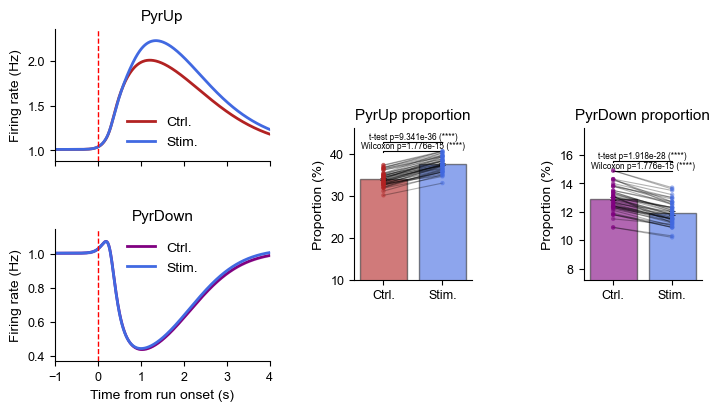

LC activation summary (mean +/- SEM):
  Ctrl. PyrUp (%): 34.08 +/- 0.23 SEM
  Stim. PyrUp (%): 37.56 +/- 0.24 SEM
  PyrUp proportion shift (%): delta = 3.48, paired t p = 9.34e-36, Wilcoxon p = 7.48e-10
  Ctrl. PyrDown (%): 12.93 +/- 0.13 SEM
  Stim. PyrDown (%): 11.92 +/- 0.11 SEM
  PyrDown proportion shift (%): delta = -1.02, paired t p = 1.92e-28, Wilcoxon p = 7.43e-10
  PyrUp 0-4 s mean firing-rate difference (Hz): delta = 0.17, paired t p = 7.62e-45, Wilcoxon p = 7.56e-10
  PyrDown 0-4 s mean firing-rate difference (Hz): delta = 0.00, paired t p = 7.29e-01, Wilcoxon p = 7.46e-01


In [ ]:
fig, ax_up, ax_down, ax_up_bar, ax_down_bar = build_experiment_axes()

base_up_plot, lc_up_plot = match_paired_pre_baseline(results['base_up_traces'], results['lc_up_traces'], results['t'], p.pre_window)
base_down_plot, lc_down_plot = match_paired_pre_baseline(results['base_down_traces'], results['lc_down_traces'], results['t'], p.pre_window)

plot_trace_pair(
    ax_up,
    results['t'],
    base_up_plot,
    lc_up_plot,
    class_colors['is_up'],
    condition_colors['lc'],
    'Ctrl.',
    'Stim.',
    'PyrUp',
    show_xlabel=False,
)
plot_trace_pair(
    ax_down,
    results['t'],
    base_down_plot,
    lc_down_plot,
    class_colors['is_down'],
    condition_colors['lc'],
    'Ctrl.',
    'Stim.',
    'PyrDown',
    show_xlabel=True,
)

plot_paired_bar_panel(
    ax_up_bar,
    results['stats']['base_up_pct'],
    results['stats']['lc_up_pct'],
    class_colors['is_up'],
    condition_colors['lc'],
    'PyrUp proportion',
    ('Ctrl.', 'Stim.'),
    10.0,
)
plot_paired_bar_panel(
    ax_down_bar,
    results['stats']['base_down_pct'],
    results['stats']['lc_down_pct'],
    class_colors['is_down'],
    condition_colors['lc'],
    'PyrDown proportion',
    ('Ctrl.', 'Stim.'),
    10.0,
)

save_figure_bundle(fig, 'general_model_experiment_1_lc_activation')

plt.show()

print('LC activation summary (mean +/- SEM):')
print_summary_line('  Ctrl. PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  Stim. PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  PyrUp proportion shift (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  Ctrl. PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  Stim. PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  PyrDown proportion shift (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])
print_trace_window_test('  PyrUp 0-4 s mean firing-rate difference (Hz)', results['base_up_traces'], results['lc_up_traces'], results['t'], (0.0, 4.0))
print_trace_window_test('  PyrDown 0-4 s mean firing-rate difference (Hz)', results['base_down_traces'], results['lc_down_traces'], results['t'], (0.0, 4.0))


## 2. DA-Targeted CA1 Cells

This section uses the baseline condition only. It compares the DA-targeted and non-targeted subsets within the same synthetic population using the same trace-plus-proportion layout as the other experiments.


Wilc p = 5.861977570020827e-14
ttest p = 2.1276689215729083e-14
Wilc p = 0.0010644297047850415
ttest p = 0.0008062267260512304


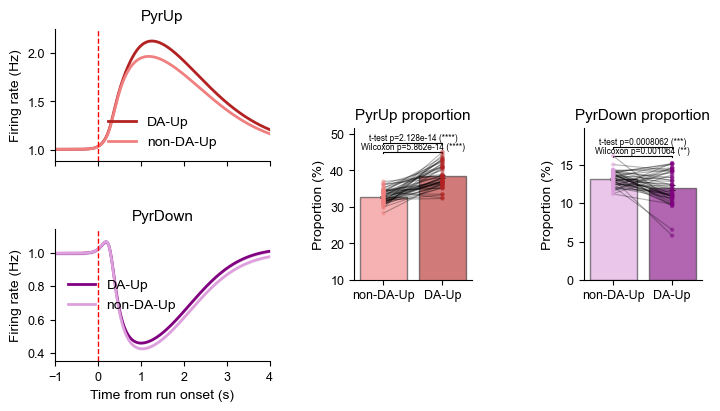

DA-targeting summary (mean +/- SEM):
  P(PyrUp | DA-Up) (%): 38.40 +/- 0.45 SEM
  P(PyrUp | non-DA-Up) (%): 32.80 +/- 0.27 SEM
  PyrUp proportion difference (%): delta = 5.60, paired t p = 2.13e-14, Wilcoxon p = 1.30e-09
  P(PyrDown | DA-Up) (%): 12.03 +/- 0.30 SEM
  P(PyrDown | non-DA-Up) (%): 13.20 +/- 0.14 SEM
  PyrDown proportion difference (%): delta = -1.17, paired t p = 8.06e-04, Wilcoxon p = 1.37e-03
  Post-run rate, DA-Up (Hz): 2.04 +/- 0.02 SEM
  Post-run rate, non-DA-Up (Hz): 1.84 +/- 0.01 SEM
  Post-run firing-rate difference (Hz): delta = 0.20, paired t p = 3.26e-15, Wilcoxon p = 1.66e-09
  PyrUp 0-4 s mean firing-rate difference (Hz): delta = 0.18, paired t p = 5.76e-17, Wilcoxon p = 1.09e-09
  PyrDown 0-4 s mean firing-rate difference (Hz): delta = -0.00, paired t p = 7.46e-01, Wilcoxon p = 5.79e-01


In [ ]:
up_non_targ_color = 'lightcoral'
up_targ_color = class_colors['is_up']
down_non_targ_color = 'plum'
down_targ_color = class_colors['is_down']

fig, ax_up, ax_down, ax_up_bar, ax_down_bar = build_experiment_axes()

da_up_plot, non_da_up_plot = match_paired_pre_baseline(results['da_up_traces'], results['non_da_up_traces'], results['t'], p.pre_window)
da_down_plot, non_da_down_plot = match_paired_pre_baseline(results['da_down_traces'], results['non_da_down_traces'], results['t'], p.pre_window)

plot_trace_pair(
    ax_up,
    results['t'],
    da_up_plot,
    non_da_up_plot,
    up_targ_color,
    up_non_targ_color,
    'DA-Up',
    'non-DA-Up',
    'PyrUp',
    show_xlabel=False,
)
plot_trace_pair(
    ax_down,
    results['t'],
    da_down_plot,
    non_da_down_plot,
    down_targ_color,
    down_non_targ_color,
    'DA-Up',
    'non-DA-Up',
    'PyrDown',
    show_xlabel=True,
)

plot_paired_bar_panel(
    ax_up_bar,
    results['stats']['p_up_not_targeted'],
    results['stats']['p_up_da_targeted'],
    up_non_targ_color,
    up_targ_color,
    'PyrUp proportion',
    ('non-DA-Up', 'DA-Up'),
    10.0,
)
plot_paired_bar_panel(
    ax_down_bar,
    results['stats']['p_down_not_targeted'],
    results['stats']['p_down_da_targeted'],
    down_non_targ_color,
    down_targ_color,
    'PyrDown proportion',
    ('non-DA-Up', 'DA-Up'),
    0.0,
)

save_figure_bundle(fig, 'general_model_experiment_2_da_targeted_subsets')

plt.show()

print('DA-targeting summary (mean +/- SEM):')
print_summary_line('  P(PyrUp | DA-Up) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | non-DA-Up) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp proportion difference (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrDown | DA-Up) (%)', results['stats']['p_down_da_targeted'])
print_summary_line('  P(PyrDown | non-DA-Up) (%)', results['stats']['p_down_not_targeted'])
print_paired_summary('  PyrDown proportion difference (%)', results['stats']['p_down_not_targeted'], results['stats']['p_down_da_targeted'])
print_summary_line('  Post-run rate, DA-Up (Hz)', results['stats']['post_rate_da_up'])
print_summary_line('  Post-run rate, non-DA-Up (Hz)', results['stats']['post_rate_non_da_up'])
print_paired_summary('  Post-run firing-rate difference (Hz)', results['stats']['post_rate_non_da_up'], results['stats']['post_rate_da_up'])
print_trace_window_test('  PyrUp 0-4 s mean firing-rate difference (Hz)', results['non_da_up_traces'], results['da_up_traces'], results['t'], (0.0, 4.0))
print_trace_window_test('  PyrDown 0-4 s mean firing-rate difference (Hz)', results['non_da_down_traces'], results['da_down_traces'], results['t'], (0.0, 4.0))


## 3. Partial DA Blockade in CA1

Within each bootstrap replicate, the blockade condition is implemented as a partial reduction of effective DA efficacy in CA1 on the same synthetic population used for baseline. This scales the post-run DA contribution rather than changing the pre-run baseline directly.


Wilc p = 1.7763568394002505e-15
ttest p = 2.4312881883234913e-31
Wilc p = 1.7763568394002505e-15
ttest p = 2.0299298886355434e-20


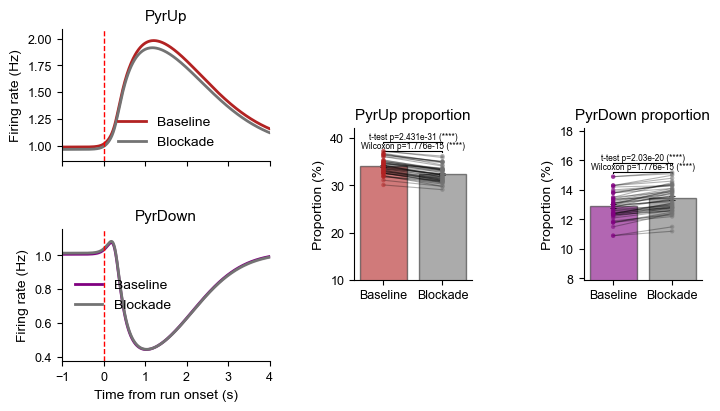

Partial DA blockade summary (mean +/- SEM):
  Baseline PyrUp (%): 34.08 +/- 0.23 SEM
  Blockade PyrUp (%): 32.47 +/- 0.23 SEM
  PyrUp proportion shift (%): delta = -1.61, paired t p = 2.43e-31, Wilcoxon p = 7.52e-10
  Baseline PyrDown (%): 12.93 +/- 0.13 SEM
  Blockade PyrDown (%): 13.43 +/- 0.13 SEM
  PyrDown proportion shift (%): delta = 0.50, paired t p = 2.03e-20, Wilcoxon p = 7.34e-10
  PyrUp 0-4 s mean firing-rate difference (Hz): delta = -0.05, paired t p = 1.66e-33, Wilcoxon p = 7.56e-10
  PyrDown 0-4 s mean firing-rate difference (Hz): delta = -0.00, paired t p = 6.50e-01, Wilcoxon p = 6.60e-01


In [ ]:
block_color = '0.45'

fig, ax_up, ax_down, ax_up_bar, ax_down_bar = build_experiment_axes()

plot_trace_pair(
    ax_up,
    results['t'],
    results['base_up_traces'],
    results['block_up_traces'],
    class_colors['is_up'],
    block_color,
    'Baseline',
    'Blockade',
    'PyrUp',
    show_xlabel=False,
)
plot_trace_pair(
    ax_down,
    results['t'],
    results['base_down_traces'],
    results['block_down_traces'],
    class_colors['is_down'],
    block_color,
    'Baseline',
    'Blockade',
    'PyrDown',
    show_xlabel=True,
)

plot_paired_bar_panel(
    ax_up_bar,
    results['stats']['base_up_pct'],
    results['stats']['block_up_pct'],
    class_colors['is_up'],
    block_color,
    'PyrUp proportion',
    ('Baseline', 'Blockade'),
    10.0,
)
plot_paired_bar_panel(
    ax_down_bar,
    results['stats']['base_down_pct'],
    results['stats']['block_down_pct'],
    class_colors['is_down'],
    block_color,
    'PyrDown proportion',
    ('Baseline', 'Blockade'),
    10.0,
)

save_figure_bundle(fig, 'general_model_experiment_3_partial_da_block')

plt.show()

print('Partial DA blockade summary (mean +/- SEM):')
print_summary_line('  Baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  Blockade PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  PyrUp proportion shift (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  Baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  Blockade PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  PyrDown proportion shift (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])
print_trace_window_test('  PyrUp 0-4 s mean firing-rate difference (Hz)', results['base_up_traces'], results['block_up_traces'], results['t'], (0.0, 4.0))
print_trace_window_test('  PyrDown 0-4 s mean firing-rate difference (Hz)', results['base_down_traces'], results['block_down_traces'], results['t'], (0.0, 4.0))


## 4. Supplemental Diagnostics

These supplemental panels summarize the model internals, class boundaries, fitted recovery statistics, and bootstrap variability of the key experiment-level effect sizes.


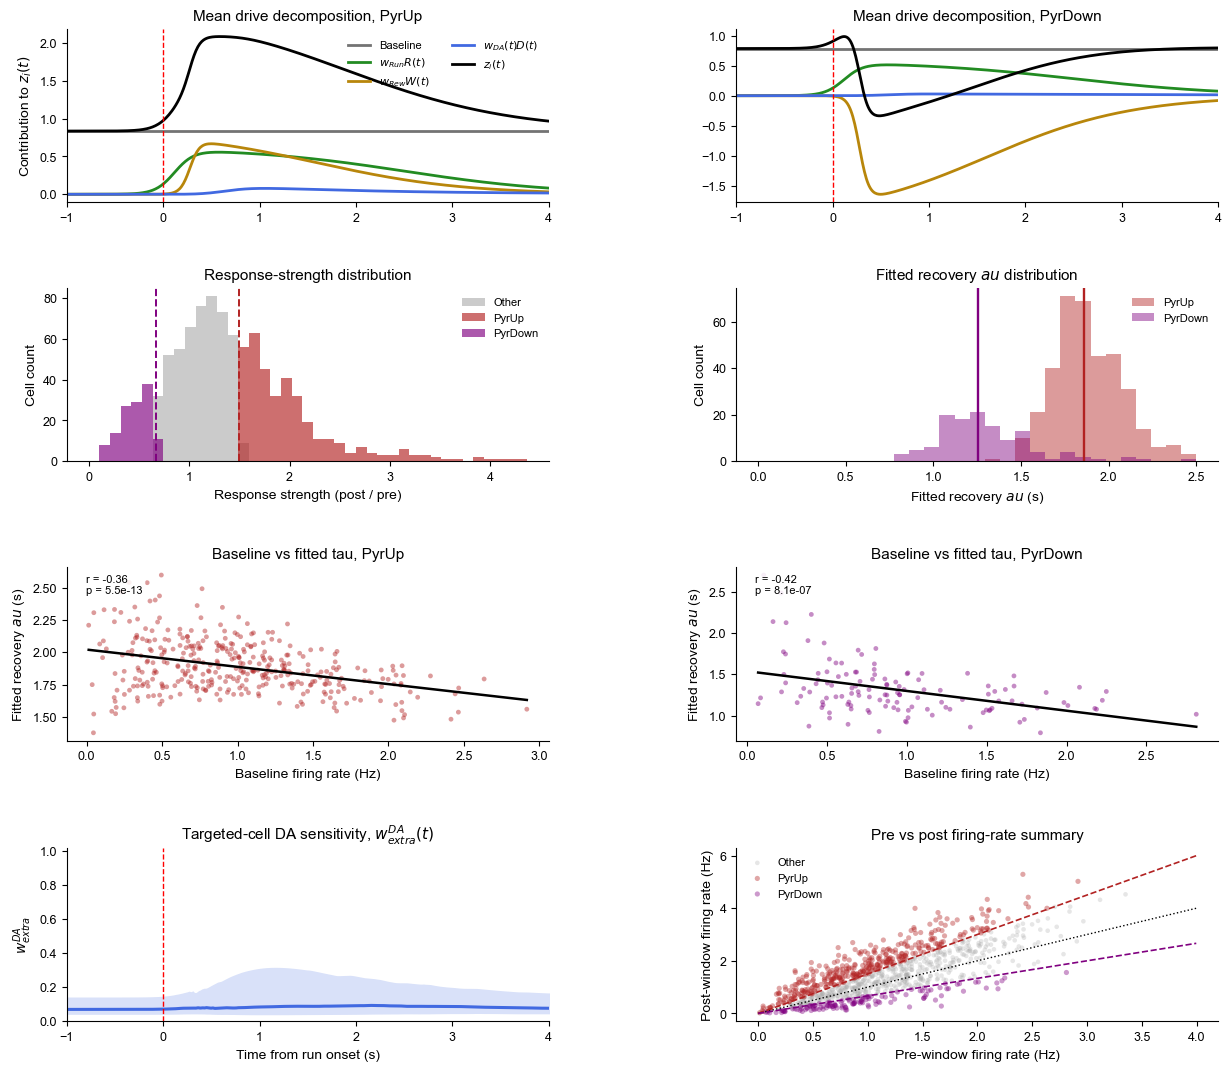

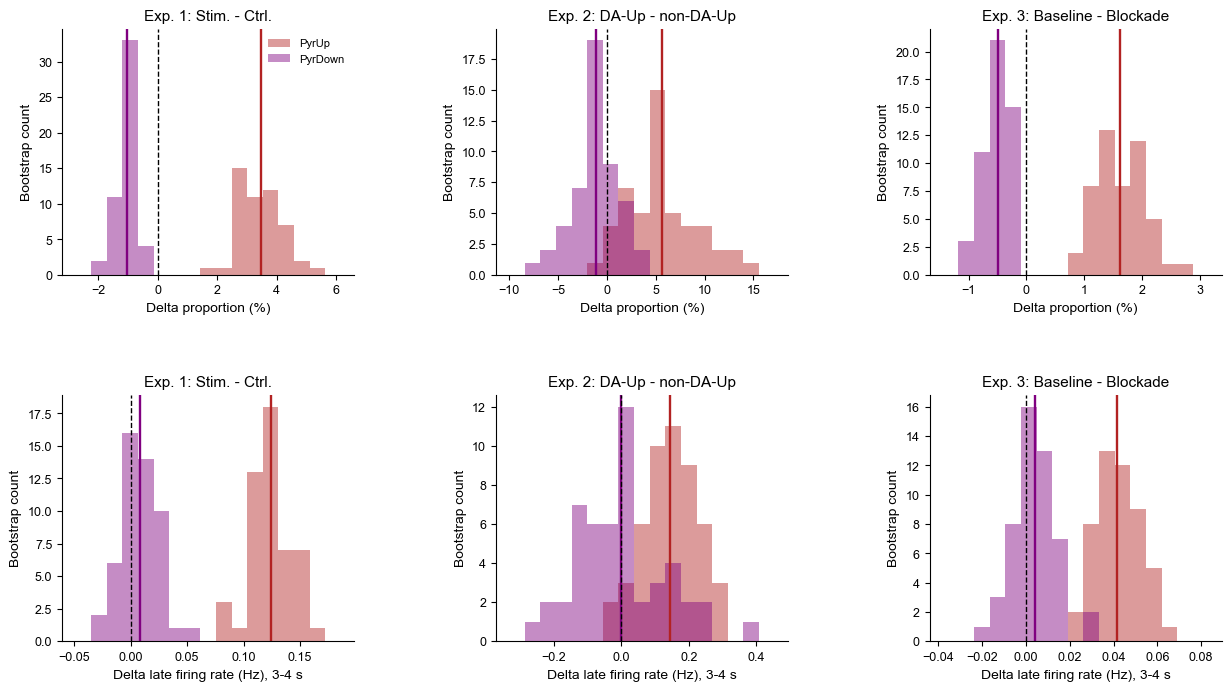

Supplemental diagnostics:
  fitted tau medians, PyrUp / PyrDown = 1.86 / 1.25 s
  baseline PyrDown / late max PyrDown = 0.94 / 0.95 Hz
  bootstrap late-tail PyrUp differences (exp1 / exp2 / exp3) = 0.124 / 0.144 / 0.042 Hz


In [ ]:
supp_t = results['t']
supp_rng = np.random.default_rng(p.seed_start)
supp_pop = make_population(p, supp_rng)
supp_base = simulate_population_condition(supp_t, p, supp_pop, da_scale=1.0)

if 'fit_population_recovery_taus' not in globals():
    def fit_cell_recovery_tau(trace, t, baseline, is_up, tau_bounds=(0.05, 6.0)):
        post_mask = (t >= 0.0) & (t <= 4.0)
        t_post = t[post_mask]
        y_post = np.asarray(trace[post_mask], dtype=float)
        if y_post.size < 8:
            return np.nan, np.nan

        extremum_idx = int(np.argmax(y_post) if is_up else np.argmin(y_post))
        t_fit = t_post[extremum_idx:]
        y_fit = y_post[extremum_idx:]
        if y_fit.size < 8:
            return np.nan, np.nan

        amp0 = float(y_fit[0] - baseline)
        if (is_up and amp0 <= p.eps) or ((not is_up) and amp0 >= -p.eps):
            return np.nan, np.nan

        amp_bound = max(abs(amp0) * 2.0, 0.25)
        amp_lower, amp_upper = ((0.0, amp_bound) if is_up else (-amp_bound, 0.0))

        def model(tt_local, amp, tau):
            return baseline + amp * np.exp(-(tt_local - t_fit[0]) / tau)

        try:
            popt, _ = curve_fit(
                model,
                t_fit,
                y_fit,
                p0=[amp0, 1.0],
                bounds=([amp_lower, tau_bounds[0]], [amp_upper, tau_bounds[1]]),
                maxfev=5000,
            )
        except Exception:
            return np.nan, np.nan

        pred = model(t_fit, *popt)
        ss_res = float(np.sum((y_fit - pred) ** 2))
        ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))
        r2 = 1.0 - ss_res / max(ss_tot, p.eps)
        return float(popt[1]), float(r2)


    def fit_population_recovery_taus(rates, t, classes):
        baseline = np.mean(rates[:, window_mask(t, p.pre_window)], axis=1)
        fitted_tau = np.full(rates.shape[0], np.nan)
        fitted_r2 = np.full(rates.shape[0], np.nan)

        for idx in np.flatnonzero(classes['is_up']):
            fitted_tau[idx], fitted_r2[idx] = fit_cell_recovery_tau(rates[idx], t, baseline[idx], True)
        for idx in np.flatnonzero(classes['is_down']):
            fitted_tau[idx], fitted_r2[idx] = fit_cell_recovery_tau(rates[idx], t, baseline[idx], False)

        return fitted_tau, fitted_r2


def masked_trace_mean(values, mask):
    if not np.any(mask):
        return np.full(values.shape[1], np.nan)
    return np.nanmean(values[mask], axis=0)


def apply_clean_axes(ax):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_bootstrap_pair(ax, left, right, left_color, right_color, title, xlabel):
    values = np.concatenate([left[np.isfinite(left)], right[np.isfinite(right)]])
    if values.size == 0:
        ax.set_axis_off()
        return
    lo = float(np.min(values))
    hi = float(np.max(values))
    span = hi - lo
    pad = max(span * 0.12, 0.02 if 'Hz' in xlabel else 0.2)
    bins = np.linspace(lo - pad, hi + pad, 18)
    ax.hist(left, bins=bins, color=left_color, alpha=0.45, density=False, label='PyrUp')
    ax.hist(right, bins=bins, color=right_color, alpha=0.45, density=False, label='PyrDown')
    ax.axvline(np.nanmean(left), color=left_color, linewidth=1.7)
    ax.axvline(np.nanmean(right), color=right_color, linewidth=1.7)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Bootstrap count')
    apply_clean_axes(ax)


supp_drives = supp_base['drives']
supp_classes = supp_base['classes']
supp_rates = supp_base['rates']

supp_pre_mask = window_mask(supp_t, p.pre_window)
supp_post_mask = window_mask(supp_t, p.post_window)
supp_tail_mask = (supp_t >= 3.0) & (supp_t <= 4.0)

x_no_da = (
    supp_pop['b'][:, None]
    + supp_pop['wR'][:, None] * supp_drives['R'][None, :]
    + supp_pop['wW'][:, None] * supp_drives['W'][None, :]
)
rate_proxy = np.column_stack([
    np.clip(softplus(x_no_da[:, 0], p.softplus_beta), 0.0, p.max_rate),
    supp_rates[:, :-1],
])
wDA_extra = sigmoid(rate_proxy, p.da_half_rate, p.da_rate_slope)
wDA_total = p.wDA_global + supp_pop['da_targ'].astype(float)[:, None] * wDA_extra

baseline_term = np.broadcast_to(supp_pop['b'][:, None], supp_rates.shape)
run_term = supp_pop['wR'][:, None] * supp_drives['R'][None, :]
rew_term = supp_pop['wW'][:, None] * supp_drives['W'][None, :]
da_term = wDA_total * supp_drives['D'][None, :]
z_total = baseline_term + run_term + rew_term + da_term

baseline_rates = np.mean(supp_rates[:, supp_pre_mask], axis=1)
post_rates = np.mean(supp_rates[:, supp_post_mask], axis=1)
fitted_tau, fitted_r2 = fit_population_recovery_taus(supp_rates, supp_t, supp_classes)

targ_extra = wDA_extra[supp_pop['da_targ']]
targ_extra_med = np.nanmedian(targ_extra, axis=0)
targ_extra_lo = np.nanpercentile(targ_extra, 10, axis=0)
targ_extra_hi = np.nanpercentile(targ_extra, 90, axis=0)

response_vals = supp_base['resp']
other_mask = supp_classes['is_other']
down_mask = supp_classes['is_down']
down_m = np.nanmean(supp_rates[down_mask], axis=0)

supp_fig = plt.figure(figsize=(12.2, 10.6), constrained_layout=True)
supp_fig.set_facecolor('white')
supp_gs = supp_fig.add_gridspec(4, 2, hspace=0.16, wspace=0.22)

ax = supp_fig.add_subplot(supp_gs[0, 0])
for label, term, color in [
    ('Baseline', baseline_term, '0.45'),
    (r'$w_{Run} R(t)$', run_term, 'forestgreen'),
    (r'$w_{Rew} W(t)$', rew_term, 'darkgoldenrod'),
    (r'$w_{DA}(t) D(t)$', da_term, 'royalblue'),
    (r'$z_i(t)$', z_total, 'black'),
]:
    ax.plot(supp_t, masked_trace_mean(term, supp_classes['is_up']), color=color, linewidth=2, label=label)
ax.axvline(0.0, linestyle='--', color='red', linewidth=1)
ax.set_xlim([-1.0, 4.0])
ax.set_title('Mean drive decomposition, PyrUp')
ax.set_ylabel(r'Contribution to $z_i(t)$')
ax.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')
apply_clean_axes(ax)

ax = supp_fig.add_subplot(supp_gs[0, 1])
for label, term, color in [
    ('Baseline', baseline_term, '0.45'),
    (r'$w_{Run} R(t)$', run_term, 'forestgreen'),
    (r'$w_{Rew} W(t)$', rew_term, 'darkgoldenrod'),
    (r'$w_{DA}(t) D(t)$', da_term, 'royalblue'),
    (r'$z_i(t)$', z_total, 'black'),
]:
    ax.plot(supp_t, masked_trace_mean(term, supp_classes['is_down']), color=color, linewidth=2, label=label)
ax.axvline(0.0, linestyle='--', color='red', linewidth=1)
ax.set_xlim([-1.0, 4.0])
ax.set_title('Mean drive decomposition, PyrDown')
apply_clean_axes(ax)

ax = supp_fig.add_subplot(supp_gs[1, 0])
resp_hi = max(3.0, float(np.nanpercentile(response_vals, 99.5)))
resp_bins = np.linspace(0.0, resp_hi, 42)
ax.hist(response_vals[other_mask], bins=resp_bins, color='0.75', alpha=0.80, label='Other')
ax.hist(response_vals[supp_classes['is_up']], bins=resp_bins, color=class_colors['is_up'], alpha=0.65, label='PyrUp')
ax.hist(response_vals[supp_classes['is_down']], bins=resp_bins, color=class_colors['is_down'], alpha=0.65, label='PyrDown')
ax.axvline(p.down_thresh, color=class_colors['is_down'], linestyle='--', linewidth=1.4)
ax.axvline(p.up_thresh, color=class_colors['is_up'], linestyle='--', linewidth=1.4)
ax.set_title('Response-strength distribution')
ax.set_xlabel('Response strength (post / pre)')
ax.set_ylabel('Cell count')
ax.legend(frameon=False, fontsize=8)
apply_clean_axes(ax)

ax = supp_fig.add_subplot(supp_gs[1, 1])
up_tau = fitted_tau[supp_classes['is_up']]
down_tau = fitted_tau[supp_classes['is_down']]
tau_vals = np.concatenate([up_tau[np.isfinite(up_tau)], down_tau[np.isfinite(down_tau)]])
tau_hi = max(2.5, float(np.nanpercentile(tau_vals, 99))) if tau_vals.size else 2.5
tau_bins = np.linspace(0.0, tau_hi, 30)
ax.hist(up_tau, bins=tau_bins, color=class_colors['is_up'], alpha=0.45, label='PyrUp')
ax.hist(down_tau, bins=tau_bins, color=class_colors['is_down'], alpha=0.45, label='PyrDown')
ax.axvline(np.nanmedian(up_tau), color=class_colors['is_up'], linewidth=1.7)
ax.axvline(np.nanmedian(down_tau), color=class_colors['is_down'], linewidth=1.7)
ax.set_title(r'Fitted recovery $	au$ distribution')
ax.set_xlabel(r'Fitted recovery $	au$ (s)')
ax.set_ylabel('Cell count')
ax.legend(frameon=False, fontsize=8)
apply_clean_axes(ax)

for ax, mask, color, title in [
    (supp_fig.add_subplot(supp_gs[2, 0]), supp_classes['is_up'], class_colors['is_up'], 'Baseline vs fitted tau, PyrUp'),
    (supp_fig.add_subplot(supp_gs[2, 1]), supp_classes['is_down'], class_colors['is_down'], 'Baseline vs fitted tau, PyrDown'),
]:
    valid = mask & np.isfinite(fitted_tau)
    x = baseline_rates[valid]
    y = fitted_tau[valid]
    ax.scatter(x, y, s=12, alpha=0.45, color=color, edgecolors='none')
    if np.sum(valid) >= 3:
        fit = linregress(x, y)
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        ax.plot(xs, fit.intercept + fit.slope * xs, color='black', linewidth=1.8)
        ax.text(
            0.04,
            0.96,
            f'r = {fit.rvalue:.2f}\np = {fit.pvalue:.1e}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.85),
        )
    ax.set_title(title)
    ax.set_xlabel('Baseline firing rate (Hz)')
    ax.set_ylabel(r'Fitted recovery $	au$ (s)')
    apply_clean_axes(ax)

ax = supp_fig.add_subplot(supp_gs[3, 0])
ax.plot(supp_t, targ_extra_med, color='royalblue', linewidth=2.2)
ax.fill_between(supp_t, targ_extra_lo, targ_extra_hi, color='royalblue', alpha=0.20, linewidth=0)
ax.axvline(0.0, linestyle='--', color='red', linewidth=1)
ax.set_xlim([-1.0, 4.0])
ax.set_ylim([0.0, 1.02])
ax.set_title(r'Targeted-cell DA sensitivity, $w_{extra}^{DA}(t)$')
ax.set_xlabel('Time from run onset (s)')
ax.set_ylabel(r'$w_{extra}^{DA}$')
apply_clean_axes(ax)

ax = supp_fig.add_subplot(supp_gs[3, 1])
ax.scatter(baseline_rates[other_mask], post_rates[other_mask], s=11, alpha=0.28, color='0.65', edgecolors='none', label='Other')
ax.scatter(baseline_rates[supp_classes['is_up']], post_rates[supp_classes['is_up']], s=14, alpha=0.40, color=class_colors['is_up'], edgecolors='none', label='PyrUp')
ax.scatter(baseline_rates[supp_classes['is_down']], post_rates[supp_classes['is_down']], s=14, alpha=0.40, color=class_colors['is_down'], edgecolors='none', label='PyrDown')
max_xy = float(np.nanpercentile(np.concatenate([baseline_rates, post_rates]), 99.5))
guide_x = np.linspace(0.0, max_xy, 100)
ax.plot(guide_x, guide_x, color='black', linewidth=1.0, linestyle=':')
ax.plot(guide_x, p.up_thresh * guide_x, color=class_colors['is_up'], linewidth=1.2, linestyle='--')
ax.plot(guide_x, p.down_thresh * guide_x, color=class_colors['is_down'], linewidth=1.2, linestyle='--')
ax.set_title('Pre vs post firing-rate summary')
ax.set_xlabel('Pre-window firing rate (Hz)')
ax.set_ylabel('Post-window firing rate (Hz)')
ax.legend(frameon=False, fontsize=8, loc='upper left')
apply_clean_axes(ax)

save_figure_bundle(supp_fig, 'general_model_supplemental_diagnostics')
plt.show()

exp_titles = ['Exp. 1: Stim. - Ctrl.', 'Exp. 2: DA-Up - non-DA-Up', 'Exp. 3: Baseline - Blockade']
prop_boot = [
    (results['stats']['lc_up_pct'] - results['stats']['base_up_pct'], results['stats']['lc_down_pct'] - results['stats']['base_down_pct']),
    (results['stats']['p_up_da_targeted'] - results['stats']['p_up_not_targeted'], results['stats']['p_down_da_targeted'] - results['stats']['p_down_not_targeted']),
    (results['stats']['base_up_pct'] - results['stats']['block_up_pct'], results['stats']['base_down_pct'] - results['stats']['block_down_pct']),
]
tail_boot = [
    (
        np.nanmean(results['lc_up_traces'][:, supp_tail_mask], axis=1) - np.nanmean(results['base_up_traces'][:, supp_tail_mask], axis=1),
        np.nanmean(results['lc_down_traces'][:, supp_tail_mask], axis=1) - np.nanmean(results['base_down_traces'][:, supp_tail_mask], axis=1),
    ),
    (
        np.nanmean(results['da_up_traces'][:, supp_tail_mask], axis=1) - np.nanmean(results['non_da_up_traces'][:, supp_tail_mask], axis=1),
        np.nanmean(results['da_down_traces'][:, supp_tail_mask], axis=1) - np.nanmean(results['non_da_down_traces'][:, supp_tail_mask], axis=1),
    ),
    (
        np.nanmean(results['base_up_traces'][:, supp_tail_mask], axis=1) - np.nanmean(results['block_up_traces'][:, supp_tail_mask], axis=1),
        np.nanmean(results['base_down_traces'][:, supp_tail_mask], axis=1) - np.nanmean(results['block_down_traces'][:, supp_tail_mask], axis=1),
    ),
]

boot_fig = plt.figure(figsize=(12.2, 6.8), constrained_layout=True)
boot_fig.set_facecolor('white')
boot_gs = boot_fig.add_gridspec(2, 3, hspace=0.18, wspace=0.22)

for col, title in enumerate(exp_titles):
    ax = boot_fig.add_subplot(boot_gs[0, col])
    plot_bootstrap_pair(ax, prop_boot[col][0], prop_boot[col][1], class_colors['is_up'], class_colors['is_down'], title, 'Delta proportion (%)')
    if col == 0:
        ax.legend(frameon=False, fontsize=8)

    ax = boot_fig.add_subplot(boot_gs[1, col])
    plot_bootstrap_pair(ax, tail_boot[col][0], tail_boot[col][1], class_colors['is_up'], class_colors['is_down'], title, 'Delta late firing rate (Hz), 3-4 s')

save_figure_bundle(boot_fig, 'general_model_supplemental_bootstrap')
plt.show()

print('Supplemental diagnostics:')
print(f'  fitted tau medians, PyrUp / PyrDown = {np.nanmedian(up_tau):.2f} / {np.nanmedian(down_tau):.2f} s')
print(f'  baseline PyrDown / late max PyrDown = {np.nanmean(down_m[supp_pre_mask]):.2f} / {np.nanmax(down_m[(supp_t >= 2.5) & (supp_t <= 4.5)]):.2f} Hz')
print(f'  bootstrap late-tail PyrUp differences (exp1 / exp2 / exp3) = {np.nanmean(tail_boot[0][0]):.3f} / {np.nanmean(tail_boot[1][0]):.3f} / {np.nanmean(tail_boot[2][0]):.3f} Hz')
